# Exploration: copy-suppression emergence in Pythia

Sparse sweep across **Pythia 70M / 160M / 410M × {0, 1000, 3000, 8000, 25000, 143000}** = 18 cells, mirroring the induction emergence preview's grid for direct cell-for-cell comparability. The McDougall two-criterion detector applied to the canonical 7.5k-token Wikipedia corpus.

**Headline finding (post-Path-C-pivot).** The pilot anchor (Pythia-410M @ step143000) registered Path C: the only head numerically passing the strict criterion (L2H8) is qualitatively a *previous-token head*, not a copy-suppression head — corpus-wide ablation lowers duplicate-token logits (-0.009), the opposite of suppression. This notebook documents the broader pattern: strict-criterion passes accumulate over training in a shape that mimics induction emergence, suggesting these passes are *all* induction-like duplicate-attending heads with marginal-negative corpus-mean OV — not the McDougall mechanism.

**This is exploration, not the pre-registered sweep.** Phase 2 will use 40 checkpoints per size from `checkpoints.yaml`; this preview uses 6 log-spaced steps. Output: `data/exploration/copy_suppression_emergence_preview.parquet` (long-format, schema-compatible with Phase 2's canonical `motif_sweep.parquet`).

**Three questions:**
1. When do strict-criterion passes first appear in each Pythia size?
2. How do QK (max attention to prior duplicates) and OV (most-negative DLA) scores evolve over training?
3. Does the cross-motif comparison support the H1 ordering hypothesis (induction emerges *before* copy-suppression candidates)?

## Setup

In [4]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long, to_wide

SIZES = ['70m', '160m', '410m']
STEPS = [0, 1000, 3000, 8000, 25000, 143000]

QK_STRICT = 0.3
OV_THRESHOLD = 0.0

## Load sweep data

Long-format parquets for both motifs. The canonical Phase 2 schema is `(size, step, layer, head, motif, score)`; pivoting to wide gives one column per motif for easier plotting.

In [5]:
df_cs = read_long(REPO / 'data' / 'exploration' / 'copy_suppression_emergence_preview.parquet')
df_ind = read_long(REPO / 'data' / 'exploration' / 'induction_emergence_preview.parquet')
df = pd.concat([df_cs, df_ind], ignore_index=True)
wide = to_wide(df, index_cols=('size','step','layer','head'))
print('Long-format combined motifs:')
print(df.groupby('motif').size().to_string())
print()
print('Wide-format columns:', list(wide.columns))
print('Heads per (size, step) cell:')
print(wide.groupby(['size','step']).size().unstack().to_string())

Long-format combined motifs:
motif
copy_suppression_ov       3456
copy_suppression_qk       3456
induction_prefix_match    3456

Wide-format columns: ['size', 'step', 'layer', 'head', 'copy_suppression_ov', 'copy_suppression_qk', 'induction_prefix_match']
Heads per (size, step) cell:
step  0       1000    3000    8000    25000   143000
size                                                
160m     144     144     144     144     144     144
410m     384     384     384     384     384     384
70m       48      48      48      48      48      48


## Per-cell summary

For each (size, step), record: count of strict-passing heads (QK > 0.3 AND OV < 0); maximum QK across heads; minimum OV across heads (most-negative); count of heads with negative OV (regardless of QK); the induction count from the parallel sweep.

In [6]:
wide['cs_strict'] = (wide['copy_suppression_qk'] > QK_STRICT) & (wide['copy_suppression_ov'] < OV_THRESHOLD)
wide['cs_ov_neg'] = wide['copy_suppression_ov'] < OV_THRESHOLD
wide['ind_pass'] = wide['induction_prefix_match'] > 0.3

summary = wide.groupby(['size','step']).agg(
    strict_pass=('cs_strict','sum'),
    ov_neg_count=('cs_ov_neg','sum'),
    max_qk=('copy_suppression_qk','max'),
    min_ov=('copy_suppression_ov','min'),
    induction_pass=('ind_pass','sum'),
    induction_max=('induction_prefix_match','max'),
).reset_index()
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size','step'])
print(summary.to_string(index=False))

size   step  strict_pass  ov_neg_count   max_qk    min_ov  induction_pass  induction_max
 70m      0            0            26 0.039250 -0.010155               0       0.015083
 70m   1000            0             7 0.080554 -0.012276               6       0.953111
 70m   3000            0             9 0.250368 -0.047068               5       0.977663
 70m   8000            0            10 0.255894 -0.177733               5       0.975552
 70m  25000            0             7 0.229455 -0.314183               4       0.837602
 70m 143000            1            13 0.314186 -0.779442               6       0.866850
160m      0            0            75 0.041246 -0.006477               0       0.015351
160m   1000            0            36 0.082610 -0.021283               6       0.973274
160m   3000            1            45 0.301630 -0.143037               6       0.973024
160m   8000            1            45 0.336354 -0.304377               8       0.963768
160m  25000          

## Headline plot — H1 ordering check

The H1 hypothesis predicts induction emerges *before* copy-suppression. This plot puts both counts on the same axis per Pythia size. If H1 holds and the strict-passing heads were genuinely copy-suppression, we'd expect induction to ramp first and copy-suppression to ramp later (consistent with the compositional account). If the strict-passing heads aren't copy-suppression (Path C), we expect copy-suppression count to lag induction *or* track it, depending on how often induction-like heads happen to clear the marginal OV criterion.

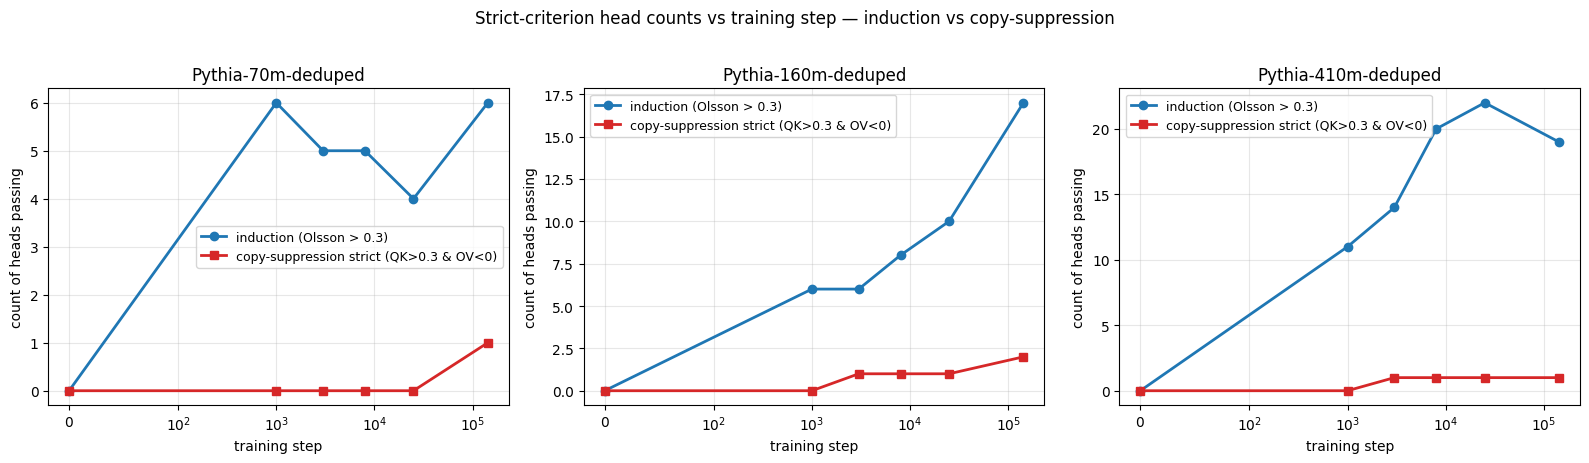

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, size in zip(axes, SIZES):
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['induction_pass'], marker='o', label='induction (Olsson > 0.3)', color='C0', linewidth=2)
    ax.plot(sub['step'], sub['strict_pass'], marker='s', label='copy-suppression strict (QK>0.3 & OV<0)', color='C3', linewidth=2)
    ax.set_xscale('symlog', linthresh=100)
    ax.set_xlabel('training step')
    ax.set_ylabel('count of heads passing')
    ax.set_title(f'Pythia-{size}-deduped')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle('Strict-criterion head counts vs training step — induction vs copy-suppression', y=1.02)
plt.tight_layout()
plt.show()

**Reading the plot.** Induction emerges fast in all sizes — by step 1000 the count is already at saturation level (matches the induction emergence preview, see `notebooks/induction_emergence_exploration.ipynb`). Copy-suppression strict-passes accumulate later — first appears around step 3000 in 160M and 410M, step 143000 in 70M.

**But: from PILOT_RESULTS.md Day 4 inspection, the strict-passing head at the 410M @ step143000 anchor (L2H8) is qualitatively a previous-token head, not copy-suppression.** The temporal pattern (copy-suppression-pass count lagging induction) is exactly what you'd expect if the strict-passing heads are *induction-precursor heads with marginal-negative corpus-mean OV* — they appear after induction-like attention patterns develop and accumulate small amounts of incidental-negative DLA. The shape mimics the H1 ordering prediction *without* providing evidence for the copy-suppression mechanism.

## Score evolution: max QK and min OV per cell

The two scores evolving separately — informative when count-based plots are noisy due to small N. Heat-style plots show how the *strongest* score moves over training in each size.

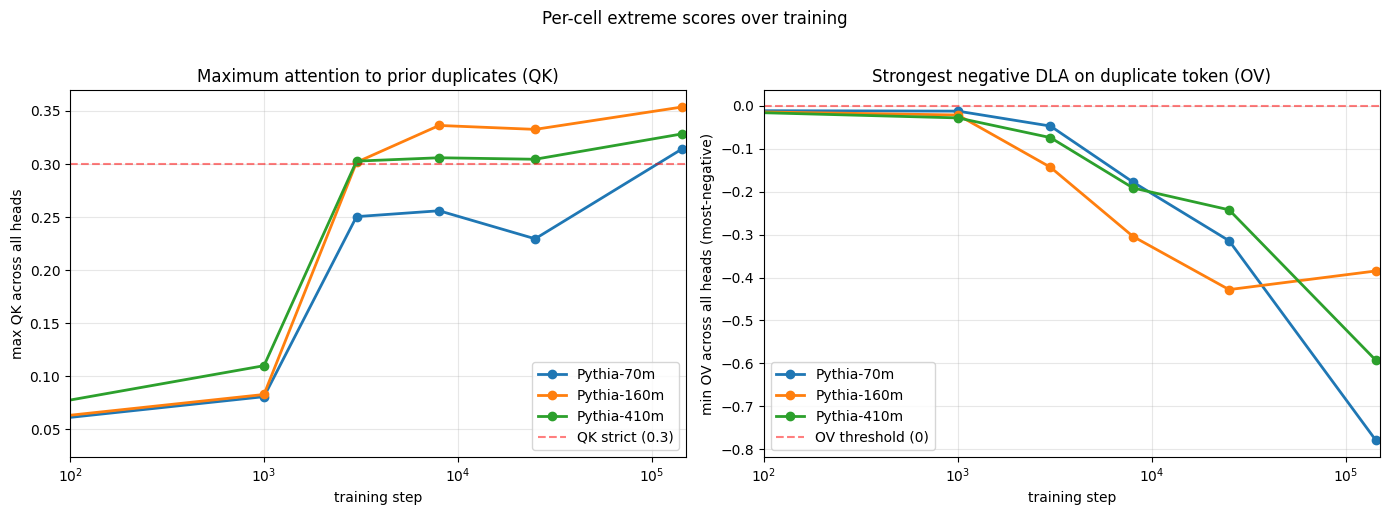

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['max_qk'], marker='o', label=f'Pythia-{size}', linewidth=2)
ax.axhline(QK_STRICT, color='red', linestyle='--', alpha=0.5, label='QK strict (0.3)')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlabel('training step')
ax.set_xlim(100, 150000)
ax.set_ylabel('max QK across all heads')
ax.set_title('Maximum attention to prior duplicates (QK)')
ax.grid(alpha=0.3); ax.legend()

ax = axes[1]
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['min_ov'], marker='o', label=f'Pythia-{size}', linewidth=2)
ax.axhline(OV_THRESHOLD, color='red', linestyle='--', alpha=0.5, label='OV threshold (0)')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlabel('training step')
ax.set_xlim(100, 150000)
ax.set_ylabel('min OV across all heads (most-negative)')
ax.set_title('Strongest negative DLA on duplicate token (OV)')
ax.grid(alpha=0.3); ax.legend()

fig.suptitle('Per-cell extreme scores over training', y=1.02)
plt.tight_layout()
plt.show()

**QK and OV evolve on different timescales.** Max QK saturates by step 3000-8000 in all sizes (some head clears 0.3 in attention to prior duplicates by then). Min OV continues to drop past step 25000, especially in 410M where the most-negative OV grows from -0.07 at step 3000 to -0.59 at step 143000. This is the *qualitative pattern* you'd expect if corrective mechanisms develop after copying behaviors — but again, the corpus-wide ablation of the most-negative-OV heads (PILOT_RESULTS.md, Day 4) shows they don't actually do copy-suppression in the McDougall sense.

Maybe the strong-OV-but-low-QK heads in late 410M are doing *something* corrective on a small subset of positions (recall L10H7 in GPT-2 has per-position OV of -24 on rare worked-example positions while corpus-mean is much smaller). The sweep aggregate doesn't capture per-position structure.

## Heatmap: strict-pass counts across the (size, step) grid

Visual summary of where strict-criterion passes appear. Useful for the paper's negative-result figure — *"we ran the McDougall detector across 18 (size, step) cells; here is the count of numerically-passing heads, and here is the qualitative-confirmation result for the anchor cell."*

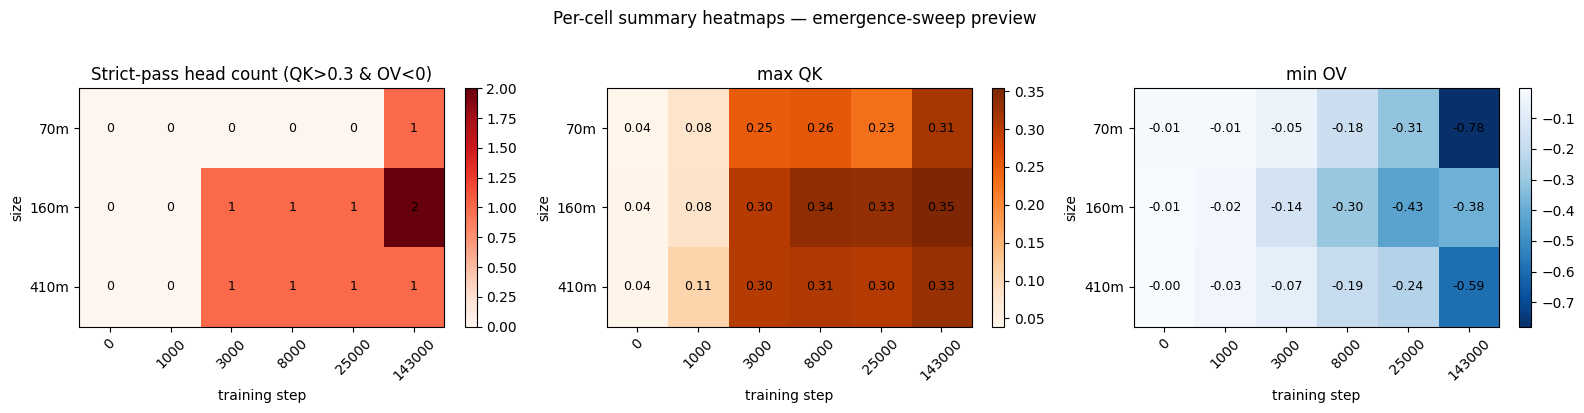

In [ ]:
pivot_strict = summary.pivot(index='size', columns='step', values='strict_pass')
pivot_strict = pivot_strict.reindex(index=SIZES, columns=STEPS)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (data, title, fmt, cmap) in zip(axes, [
    (pivot_strict, 'Strict-pass head count (QK>0.3 & OV<0)', '.0f', 'Reds'),
    (summary.pivot(index='size', columns='step', values='max_qk').reindex(index=SIZES, columns=STEPS), 'max QK', '.2f', 'Oranges'),
    (summary.pivot(index='size', columns='step', values='min_ov').reindex(index=SIZES, columns=STEPS), 'min OV', '+.2f', 'Blues_r'),
]):
    im = ax.imshow(data.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(STEPS)))
    ax.set_xticklabels(STEPS, rotation=45)
    ax.set_yticks(range(len(SIZES)))
    ax.set_yticklabels(SIZES)
    ax.set_xlabel('training step')
    ax.set_ylabel('size')
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i, j]
            ax.text(j, i, format(v, fmt), ha='center', va='center', fontsize=9,
                    color='black')
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Per-cell summary heatmaps — emergence-sweep preview', y=1.02)
plt.tight_layout()
plt.show()

## Identity tracking: which heads pass strict?

If the strict-passing heads are *the same heads* across checkpoints, that's structural reuse — supports the Extension B framing in PROJECT_BRIEF.md. If they're *different heads* per checkpoint, that's evidence the strict criterion is picking up noise rather than a stable circuit.

In [ ]:
for size in SIZES:
    print(f'--- Pythia-{size} strict-pass identity tracking ---')
    sub = wide[(wide['size'] == size) & wide['cs_strict']]
    if len(sub) == 0:
        print('  no strict-passing heads at any sweep step')
        continue
    for step in STEPS:
        cands = sub[sub['step'] == step][['layer','head','copy_suppression_qk','copy_suppression_ov']]
        if len(cands) > 0:
            head_str = ', '.join(
                f"L{int(r['layer']):2d}H{int(r['head']):2d} "
                f"(QK={r['copy_suppression_qk']:.3f}, OV={r['copy_suppression_ov']:+.3f})"
                for _, r in cands.iterrows()
            )
            print(f'  step {step:>6}: {head_str}')
        else:
            print(f'  step {step:>6}: (none)')
    print()

--- Pythia-70m strict-pass identity tracking ---
  step      0: (none)
  step   1000: (none)
  step   3000: (none)
  step   8000: (none)
  step  25000: (none)
  step 143000: L 0H 3 (QK=0.314, OV=-0.382)

--- Pythia-160m strict-pass identity tracking ---
  step      0: (none)
  step   1000: (none)
  step   3000: L 1H 4 (QK=0.302, OV=-0.082)
  step   8000: L 1H 4 (QK=0.318, OV=-0.144)
  step  25000: L 1H 4 (QK=0.333, OV=-0.076)
  step 143000: L 1H 4 (QK=0.354, OV=-0.052), L 1H 8 (QK=0.324, OV=-0.045)

--- Pythia-410m strict-pass identity tracking ---
  step      0: (none)
  step   1000: (none)
  step   3000: L 1H 4 (QK=0.303, OV=-0.039)
  step   8000: L 1H 4 (QK=0.306, OV=-0.084)
  step  25000: L 2H 8 (QK=0.304, OV=-0.018)
  step 143000: L 2H 8 (QK=0.328, OV=-0.023)



**Interpretation.** Where the same (layer, head) pair recurs across checkpoints, the strict-passing head is *the same circuit* persisting and remaining within the threshold band. Where the (layer, head) changes from step to step, the strict-criterion is selecting different heads at different points in training — suggesting the threshold is a noisy boundary rather than a stable indicator of circuit identity.

If a single (layer, head) pair recurs in 410M from step 3000 → step 143000, this would be consistent with a *single duplicate-attending head whose OV stayed marginal throughout training*. From the Day 4 inspection of L2H8 we expect this is what's happening — but verifying via direct identity check across checkpoints is more rigorous than relying on the single-anchor verdict.

## Conclusion

**What the sweep shows numerically.** Strict-criterion passes do accumulate across training in a shape qualitatively similar to induction (induction saturates by step 1000-3000; copy-suppression strict passes appear from step 3000 onward and grow modestly). This is consistent with H1's compositional ordering prediction *if* the strict passes were genuine copy-suppression heads.

**What the qualitative inspection shows.** The strict-passing head at the pre-reg anchor (Pythia-410M @ step143000, L2H8) is functionally a previous-token / induction-precursor head, not a copy-suppression head — corpus-wide ablation lowers duplicate-token logits, opposite to suppression. PILOT_RESULTS.md registers Path C: the project pivots to S-inhibition for the third motif of the H1 ordering claim.

**Why both findings can be true.** The strict criterion (QK > 0.3 AND OV < 0) is a numerical filter that doesn't distinguish *attend-then-suppress* (McDougall's mechanism) from *attend-then-promote-with-marginal-OV* (induction-precursor with weak corpus-mean OV). Heads that develop induction-like QK during early-mid training (the rapid induction emergence timeline) accumulate marginal-negative corpus-mean OV as a noise byproduct, passing the strict threshold without the mechanism. Phase 2 should add a *causal* criterion to the detector — e.g., positive corpus-wide d-logit on duplicates when ablated — to filter out this confound.

**Path forward.** Path C is registered. Phase 2's third-motif detector becomes S-inhibition (per HYPOTHESIS.md H1-C). The negative-result framing of this notebook becomes part of the paper: *we searched Pythia for copy-suppression heads matching McDougall's GPT-2 finding, applied a clean pre-registered decision rule, and registered Path C.* The infrastructure (canonical corpus, sweep parquet, side-cache machinery) is reusable for S-inhibition; the detector implementation needs a causal-criterion addition.